This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [8]:
!pip install keras keras-hub --upgrade -q

In [9]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [10]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [11]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-05 04:59:42--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 3.5.1.201, 16.15.223.205, 52.217.137.216, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|3.5.1.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip.1’

jena_climate_2009_2 100%[===================>]  12.94M  63.1MB/s    in 0.2s    

2026-03-05 04:59:42 (63.1 MB/s) - ‘jena_climate_2009_2016.csv.zip.1’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
replace jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: jena_climae_2009_2016_48hrs.csv
  inflating: jena_climae_2009_2016_48hrs.csv  
replace __MACOSX/._jena_climate_2009_2016.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [12]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [13]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

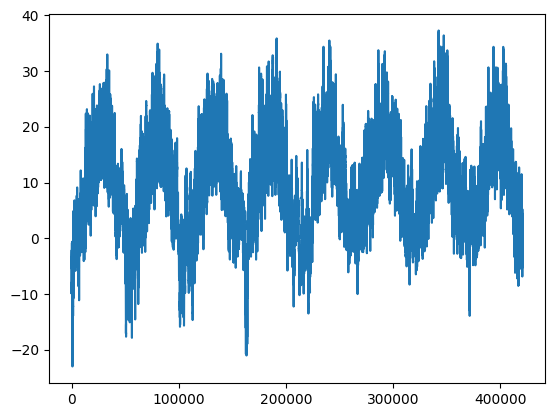

In [14]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

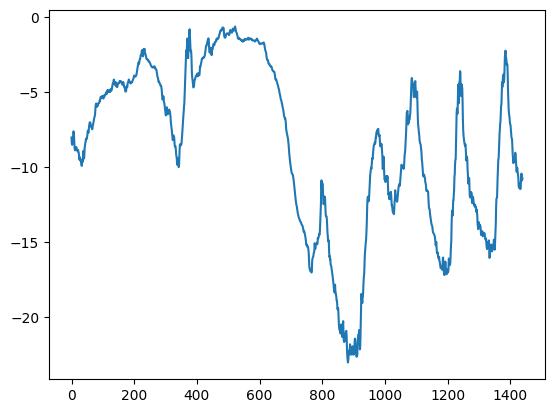

In [15]:
plt.plot(range(1440), temperature[:1440])

In [16]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

In [17]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [18]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [19]:
sampling_rate = 6
sequence_length = 120
#delay = sampling_rate * (sequence_length + 24 - 1)
delay = sampling_rate * (sequence_length + 48 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [20]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline

In [21]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 3.21
Test MAE: 3.47


#### Let's try a basic machine learning model

In [22]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - loss: 18.8431 - mae: 3.3926 - val_loss: 16.5456 - val_mae: 3.2231
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 52ms/step - loss: 13.6286 - mae: 2.9374 - val_loss: 15.8213 - val_mae: 3.1568
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 12.7152 - mae: 2.8332 - val_loss: 16.3142 - val_mae: 3.1987
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 12.0779 - mae: 2.7563 - val_loss: 16.3178 - val_mae: 3.2021
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.5195 - mae: 2.6918 - val_loss: 16.8202 - val_mae: 3.2479
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.1432 - mae: 2.6476 - val_loss: 17.1755 - val_mae: 3.2699
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 10.7637 - mae: 2.6025 - val_loss: 17.2853 - val_mae: 3.2800
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 10.4998 - mae: 2.5678 - val_loss: 17.9615 - val_mae: 3.3565
Epoch 9/10
819/819 ━━━━━

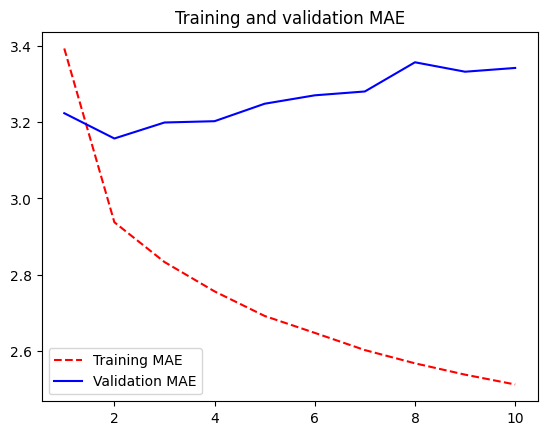

In [23]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [24]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - loss: 25.9457 - mae: 3.9652 - val_loss: 21.2785 - val_mae: 3.6622
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 15.7895 - mae: 3.1505 - val_loss: 20.9550 - val_mae: 3.6280
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 13.9479 - mae: 2.9526 - val_loss: 21.4510 - val_mae: 3.6638
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 12.7928 - mae: 2.8198 - val_loss: 23.7144 - val_mae: 3.7809
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.0258 - mae: 2.7316 - val_loss: 22.2134 - val_mae: 3.7053
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 11.4963 - mae: 2.6724 - val_loss: 24.3255 - val_mae: 3.8540
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 11.0106 - mae: 2.6152 - val_loss: 24.0634 - val_mae: 3.8198
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 10.5499 - mae: 2.5610 - val_loss: 24.2246 - val_mae: 3.8569
Epoch 9/10
819/819 ━━━━━

### Recurrent neural networks

In [25]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - loss: 48.2018 - mae: 5.2386 - val_loss: 22.6176 - val_mae: 3.6452
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 19.3371 - mae: 3.4135 - val_loss: 17.4723 - val_mae: 3.2405
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 16.4768 - mae: 3.1945 - val_loss: 16.4910 - val_mae: 3.1788
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 15.6242 - mae: 3.1215 - val_loss: 16.5126 - val_mae: 3.1944
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 15.1976 - mae: 3.0829 - val_loss: 16.2691 - val_mae: 3.1591
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 14.5828 - mae: 3.0198 - val_loss: 16.3671 - val_mae: 3.1744
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 14.2707 - mae: 2.9856 - val_loss: 16.6638 - val_mae: 3.2054
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 13.8426 - mae: 2.9416 - val_loss: 16.6850 - val_mae: 3.2117
Epoch 9/10
819/819 ━━━━━

#### Understanding recurrent neural networks

In [26]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

#### A recurrent layer in Keras

In [27]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [28]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [29]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [30]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### Getting the most out of recurrent neural networks

#### Using recurrent dropout to fight overfitting

In [31]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - loss: 38.0547 - mae: 4.6703 - val_loss: 16.8585 - val_mae: 3.1757
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 21.4931 - mae: 3.6377 - val_loss: 15.2691 - val_mae: 3.0451
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 58s 71ms/step - loss: 20.2431 - mae: 3.5299 - val_loss: 14.9372 - val_mae: 3.0142
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 19.5134 - mae: 3.4650 - val_loss: 14.7010 - val_mae: 2.9956
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 18.9344 - mae: 3.4105 - val_loss: 14.9798 - val_mae: 3.0193
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 18.4199 - mae: 3.3629 - val_loss: 15.0074 - val_mae: 3.0374
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 18.0465 - mae: 3.3282 - val_loss: 15.1671 - val_mae: 3.0365
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 17.6302 - mae: 3.2896 - val_loss: 15.0717 - val_mae: 3.0395
Epoch 9/50
819/819 ━━━━━

#### Stacking recurrent layers

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 57s 65ms/step - loss: 34.0654 - mae: 4.4395 - val_loss: 16.0056 - val_mae: 3.0968
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 20.4893 - mae: 3.5450 - val_loss: 14.5450 - val_mae: 2.9889
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 19.0961 - mae: 3.4215 - val_loss: 14.3926 - val_mae: 2.9770
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 18.1122 - mae: 3.3328 - val_loss: 14.5231 - val_mae: 2.9853
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 17.2511 - mae: 3.2490 - val_loss: 14.5722 - val_mae: 3.0125
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 16.4101 - mae: 3.1735 - val_loss: 14.8466 - val_mae: 3.0303
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 15.7949 - mae: 3.1071 - val_loss: 15.0315 - val_mae: 3.0554
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 15.1840 - mae: 3.0475 - val_loss: 15.8517 - val_mae: 3.1274
Epoch 9/50
819/819 ━━━━━

#### Using bidirectional RNNs

In [33]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - loss: 35.2774 - mae: 4.4179 - val_loss: 16.7156 - val_mae: 3.2104
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 15.9544 - mae: 3.1555 - val_loss: 15.4447 - val_mae: 3.0876
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 13.9683 - mae: 2.9519 - val_loss: 15.5269 - val_mae: 3.0972
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - loss: 12.6380 - mae: 2.8038 - val_loss: 15.7101 - val_mae: 3.1157
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 11.8251 - mae: 2.7106 - val_loss: 15.4325 - val_mae: 3.0899
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 80s 58ms/step - loss: 11.7082 - mae: 2.6969 - val_loss: 15.7578 - val_mae: 3.1261
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 11.2570 - mae: 2.6416 - val_loss: 16.0177 - val_mae: 3.1602
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 11.1451 - mae: 2.6341 - val_loss: 15.9568 - val_mae: 3.1517
Epoch 9/10
819/819 ━━━━━

### Going even further